# Crop Yield Prediction - Regression Modeling

## 🤖 Xây Dựng Và Huấn Luyện Các Mô Hình

Notebook này:
1. **Load processed data** - Tải dữ liệu đã xử lý
2. **Create models** - Tạo các models
3. **Train models** - Huấn luyện
4. **Evaluate models** - Đánh giá

---

In [1]:
import sys
from pathlib import Path

# Thêm src vào path để import modules
src_path = Path('../src')
sys.path.insert(0, str(src_path.absolute()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Import modules
from models.regression import RegressionModels

print("✓ Đã import tất cả thư viện")

✓ Đã import tất cả thư viện


In [2]:
# Tải dữ liệu từ cleaned data
data_path = Path('../data/processed/feature_engineered_data.csv')

if not data_path.exists():
    print("⚠️  Processed data không tìm thấy!")
    print(f"   Tạo data từ cleaned data...")
    
    from data.loader import DataLoader
    loader = DataLoader(data_dir="../data/raw/cleaned", use_cleaned=True)
    df, _ = loader.get_complete_dataset()
    print(f"✓ Đã tải dữ liệu từ cleaned data")
else:
    df = pd.read_csv(data_path)
    print(f"✓ Đã tải dữ liệu")

print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()[:5]}...")

✓ Đã tải dữ liệu
   Shape: (28242, 16)
   Columns: ['Year', 'Pesticides', 'Temperature', 'Area_Australia', 'Area_Ecuador']...


In [3]:
# Tách features và target
target_col = 'Yield'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\n📊 Feature Matrix: {X.shape}")
print(f"📊 Target: {y.shape}")

print(f"\nTarget Statistics:")
print(f"   Mean: {y.mean():.2f}")
print(f"   Std: {y.std():.2f}")
print(f"   Min: {y.min():.2f}")
print(f"   Max: {y.max():.2f}")


📊 Feature Matrix: (28242, 15)
📊 Target: (28242,)

Target Statistics:
   Mean: 71740.88
   Std: 69980.89
   Min: 50.00
   Max: 231813.00


## 1. Split Data into Train & Test

In [4]:
# Split data
test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)

print(f"\n📊 Data Split:")
print(f"   Train set: {X_train.shape}")
print(f"   Test set: {X_test.shape}")
print(f"   Test size ratio: {test_size*100:.1f}%")

print(f"\n✓ y_train: {y_train.shape}")
print(f"✓ y_test: {y_test.shape}")


📊 Data Split:
   Train set: (22593, 15)
   Test set: (5649, 15)
   Test size ratio: 20.0%

✓ y_train: (22593,)
✓ y_test: (5649,)


## 2. Create & Configure Models

In [5]:
# Khởi tạo RegressionModels
regressor = RegressionModels()

# Tạo models
models = regressor.create_models()

print(f"\n✓ Đã tạo {len(models)} models")


🏗️  TẠO CÁC MÔ HÌNH REGRESSION

   📌 BASELINE MODELS:
      • Linear Regression
      • Ridge Regression (alpha=1.0)

   🚀 ADVANCED MODELS:
      • Random Forest (100 estimators)
      • XGBoost (skip - chưa cài package xgboost)

   ✓ Đã tạo 3 models

✓ Đã tạo 3 models


## 3. Train Models

In [6]:
# Huấn luyện models
trained_models = regressor.train_models(X_train, y_train)

print(f"\n✓ Đã huấn luyện {len(trained_models)} models")


🎯 HUẤN LUYỆN CÁC MÔ HÌNH

   Training data shape: (22593, 15)

   Linear Regression...
      ✓ Hoàn thành!

   Ridge Regression...
      ✓ Hoàn thành!

   Random Forest...
      ✓ Hoàn thành!

   ✓ Đã huấn luyện 3/3 models

✓ Đã huấn luyện 3 models


## 4. Evaluate Models on Test Set

In [7]:
# Đánh giá models trên test set
results_df = regressor.evaluate_models(X_test, y_test)

print("\n" + "="*80)
print("📊 MODEL EVALUATION ON TEST SET")
print("="*80)

display(results_df.sort_values('R2', ascending=False))


📊 ĐÁNH GIÁ CÁC MÔ HÌNH TRÊN TEST SET

   Test data shape: (5649, 15)

   Linear Regression:
      • MAE:  55530.2273
      • RMSE: 67802.4627
      • R²:   0.0642
      • MAPE: 213.97%

   Ridge Regression:
      • MAE:  55534.1234
      • RMSE: 67802.9224
      • R²:   0.0642
      • MAPE: 214.02%

   Random Forest:
      • MAE:  58121.7338
      • RMSE: 71006.0747
      • R²:   -0.0263
      • MAPE: 201.20%

📊 MODEL EVALUATION ON TEST SET


,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,55530.227340,67802.462732,0.064216,213.968907
1,Ridge Regression,55534.123403,67802.922351,0.064203,214.015241
2,Random Forest,58121.733773,71006.074684,-0.026304,201.198880


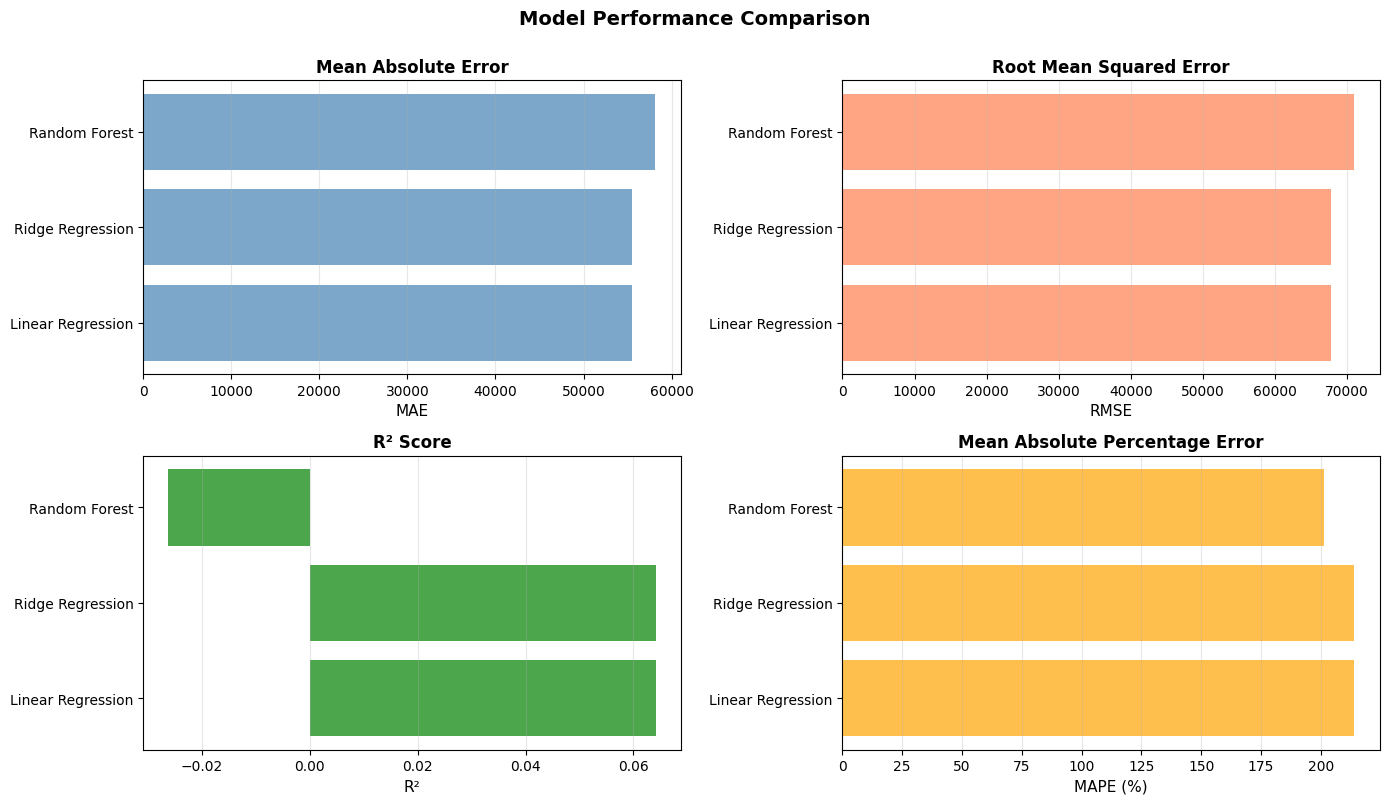

✓ Biểu đồ so sánh đã vẽ


In [8]:
# Vẽ biểu đồ so sánh models
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

results_sorted = results_df.sort_values('R2', ascending=False)

# MAE
axes[0, 0].barh(results_sorted['Model'], results_sorted['MAE'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('MAE', fontsize=11)
axes[0, 0].set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# RMSE
axes[0, 1].barh(results_sorted['Model'], results_sorted['RMSE'], color='coral', alpha=0.7)
axes[0, 1].set_xlabel('RMSE', fontsize=11)
axes[0, 1].set_title('Root Mean Squared Error', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

# R²
axes[1, 0].barh(results_sorted['Model'], results_sorted['R2'], color='green', alpha=0.7)
axes[1, 0].set_xlabel('R²', fontsize=11)
axes[1, 0].set_title('R² Score', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')

# MAPE
axes[1, 1].barh(results_sorted['Model'], results_sorted['MAPE'], color='orange', alpha=0.7)
axes[1, 1].set_xlabel('MAPE (%)', fontsize=11)
axes[1, 1].set_title('Mean Absolute Percentage Error', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Biểu đồ so sánh đã vẽ")

## 5. Cross-Validation

In [9]:
# Cross-validation (5-fold)
cv_results = regressor.cross_validation(X, y, cv_folds=5)

print("\n" + "="*80)
print("📊 CROSS-VALIDATION RESULTS (5-FOLD)")
print("="*80)

display(cv_results.sort_values('R2_Mean', ascending=False))


🔄 CROSS-VALIDATION (5-FOLD)

   Data shape: (28242, 15)

   Linear Regression:
      • R² Mean:   0.0622 ± 0.0018
      • MAE Mean:  55608.9119 ± 455.4035
      • RMSE Mean: 67764.1458 ± 420.5725

   Ridge Regression:
      • R² Mean:   0.0623 ± 0.0018
      • MAE Mean:  55612.0456 ± 455.2975
      • RMSE Mean: 67764.0510 ± 420.8695

   Random Forest:
      • R² Mean:   -0.0242 ± 0.0106
      • MAE Mean:  58189.6841 ± 281.1437
      • RMSE Mean: 70815.1585 ± 286.8037

📊 CROSS-VALIDATION RESULTS (5-FOLD)


,Model,R2_Mean,R2_Std,MAE_Mean,MAE_Std,RMSE_Mean,RMSE_Std
1,Ridge Regression,0.062252,0.001826,55612.045639,455.297486,67764.050976,420.869549
0,Linear Regression,0.062249,0.001838,55608.911918,455.403494,67764.145837,420.572534
2,Random Forest,-0.024171,0.010632,58189.684103,281.143735,70815.158542,286.803655


## 6. Best Model Selection

In [10]:
# Tìm model tốt nhất
best_model_name, best_r2 = regressor.get_best_model()

print("\n" + "="*80)
print("🏆 BEST MODEL SELECTED")
print("="*80)

print(f"\n⭐ {best_model_name}")

# Lấy chi tiết best model
best_model_details = results_df[results_df['Model'] == best_model_name].iloc[0]

print(f"\n📊 Performance:")
print(f"   • MAE:  {best_model_details['MAE']:.4f}")
print(f"   • RMSE: {best_model_details['RMSE']:.4f}")
print(f"   • R²:   {best_model_details['R2']:.4f}")
print(f"   • MAPE: {best_model_details['MAPE']:.4f}%")


🏆 BEST MODEL SELECTED

⭐ Linear Regression

📊 Performance:
   • MAE:  55530.2273
   • RMSE: 67802.4627
   • R²:   0.0642
   • MAPE: 213.9689%


In [11]:
# Feature importance từ best model
if best_model_name in ['Random Forest', 'XGBoost']:
    print(f"\n📊 Feature Importance từ {best_model_name}:")
    
    importance_df = regressor.get_feature_importance(best_model_name, X_train.columns.tolist())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    importance_top = importance_df.head(15)
    
    ax.barh(importance_top['Feature'], importance_top['Importance'], 
           color='steelblue', edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️  {best_model_name} không hỗ trợ feature importance")


⚠️  Linear Regression không hỗ trợ feature importance


## 7. Save Models

In [12]:
# Lưu models
output_dir = Path('../outputs/models')
output_dir.mkdir(parents=True, exist_ok=True)

for model_name in regressor.trained_models.keys():
    filepath = output_dir / f"{model_name.replace(' ', '_')}.pkl"
    regressor.save_model(model_name, str(filepath))

print(f"\n✓ Các models đã lưu vào: {output_dir}")

💾 Đã lưu Linear Regression: ..\outputs\models\Linear_Regression.pkl
💾 Đã lưu Ridge Regression: ..\outputs\models\Ridge_Regression.pkl
💾 Đã lưu Random Forest: ..\outputs\models\Random_Forest.pkl

✓ Các models đã lưu vào: ..\outputs\models


## 8. Summary

In [13]:
# Tóm tắt
print("\n" + "="*80)
print("✅ MODELING HOÀN TẤT")
print("="*80)

print(f"\n📊 Summary:")
print(f"   • Models trained: {len(regressor.trained_models)}")
print(f"   • Best model: {best_model_name}")
print(f"   • Best R² score: {best_r2:.4f}")
print(f"   • Train size: {X_train.shape[0]} samples")
print(f"   • Test size: {X_test.shape[0]} samples")
print(f"   • Features used: {X_train.shape[1]}")

print(f"\n📈 Model Rankings (by R²):")
for idx, (_, row) in enumerate(results_df.sort_values('R2', ascending=False).iterrows(), 1):
    print(f"   {idx}. {row['Model']:20s} - R²: {row['R2']:.4f}, MAE: {row['MAE']:.4f}")


✅ MODELING HOÀN TẤT

📊 Summary:
   • Models trained: 3
   • Best model: Linear Regression
   • Best R² score: 0.0642
   • Train size: 22593 samples
   • Test size: 5649 samples
   • Features used: 15

📈 Model Rankings (by R²):
   1. Linear Regression    - R²: 0.0642, MAE: 55530.2273
   2. Ridge Regression     - R²: 0.0642, MAE: 55534.1234
   3. Random Forest        - R²: -0.0263, MAE: 58121.7338
